In [12]:
import numpy as np
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [13]:
conn=sqlite3.connect("customer_churn.db")

sql_query="""
select name from sqlite_master where type='table'
"""

tables=pd.read_sql(sql_query,conn)

#Create dataframe for each table
for table_name in tables["name"]:
    df=pd.read_sql(f"select *from {table_name}",conn)
    globals()[f"df_{table_name}"]=df
    print(f"Created dataframe: df_{table_name}")
conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [14]:
#Print table names and column names
conn=sqlite3.connect("customer_churn.db")

for table_name in tables["name"]:
    print(f"\nTable Name: {table_name}")
    #Get column information
    columns_query=f"PRAGMA table_info({table_name});"
    columns=pd.read_sql(columns_query,conn)
    print("Columns: ")
    print(columns["name"].tolist())

conn.close()


Table Name: db_customer
Columns: 
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns: 
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns: 
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [15]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [16]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [17]:
df_db_customer.rename(columns={"name":"customer_name"},inplace=True)

In [18]:
df_db_customer.head()

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [19]:
df_db_customer.drop(["interests","pincode"],axis=1,inplace=True)

In [20]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     21 non-null     object
 1   customer_name  21 non-null     object
 2   country        18 non-null     object
 3   state          21 non-null     object
 4   gender         21 non-null     object
 5   dob            21 non-null     object
dtypes: object(6)
memory usage: 1.1+ KB


In [21]:
df_db_customer["dob"]=pd.to_datetime(df_db_customer["dob"])

In [22]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     object        
 1   customer_name  21 non-null     object        
 2   country        18 non-null     object        
 3   state          21 non-null     object        
 4   gender         21 non-null     object        
 5   dob            21 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 1.1+ KB


In [23]:
df_db_customer["gender"].unique()

array(['Male', 'Female', 'Women', 'Men'], dtype=object)

In [24]:
df_db_customer["gender"].replace({"Men":"Male","Women":"Female"},inplace=True)

In [25]:
df_db_customer["gender"].value_counts()

gender
Female    12
Male       9
Name: count, dtype: int64

In [26]:
df_db_customer["country"].value_counts()

country
India    17
Nepal     1
Name: count, dtype: int64

In [27]:
df_db_customer[df_db_customer["country"].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [28]:
state_country_mapping=df_db_customer.dropna(subset=["country"]).set_index("state")["country"].to_dict()

In [29]:
df_db_customer["country"].fillna(df_db_customer["state"].map(state_country_mapping),inplace=True)

In [30]:
df_db_customer.isnull().sum()

customerid       0
customer_name    0
country          0
state            0
gender           0
dob              0
dtype: int64

In [31]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [32]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [33]:
date_cols=["subscription_start_date","renewal_date","cancellation_date"]

df_db_subscription[date_cols]=df_db_subscription[date_cols].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [34]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [35]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 560.0+ bytes


In [36]:
df_db_support.drop(["col_1","comment"],axis=1,inplace=True)

In [37]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
dtypes: int64(1), object(3)
memory usage: 416.0+ bytes


In [38]:
df_db_support["complaint_date"]=pd.to_datetime(df_db_support["complaint_date"])

In [39]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 416.0+ bytes


**Feature Engineering and Data Analysis**

In [40]:
df_db_subscription["churn_flag"]=np.where(df_db_subscription["cancellation_date"].notna(),1,0)

In [41]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [42]:
#First fix support table duplicates then merge
df=(df_db_subscription.merge(df_db_customer,on="customerid",how="left").merge(df_db_support,on="customerid",how="left"))

In [43]:
df.shape

(23, 20)

In [44]:
df_db_subscription["customerid"].nunique()

21

In [45]:
df_db_customer["customerid"].nunique()

21

In [46]:
df_db_support["customerid"].nunique()

7

In [47]:
df_db_support["customerid"].size

9

In [48]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [49]:
df_db_support["complaint_count"]=df_db_support.groupby("customerid")["customerid"].transform("count")

In [50]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [51]:
df_db_support=df_db_support.sort_values("complaint_date").drop_duplicates("customerid",keep="last")

In [52]:
df_db_support["customerid"].size

7

In [53]:
#merge df
df=(df_db_subscription.merge(df_db_customer,on="customerid",how="left").merge(df_db_support,on="customerid",how="left"))

In [54]:
df.shape

(21, 21)

In [55]:
df.to_csv("exported_churn_data.csv",index=False)

**Data Analysis**

In [56]:
#1.Churn Rate

In [57]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [58]:
df['escalations'].unique()

array([nan, 'Y', 'N'], dtype=object)

In [59]:
churn_rate=df["churn_flag"].mean()*100
print("Churn Rate=",round(churn_rate,2),"%")

Churn Rate= 28.57 %


In [60]:
#2.Retention Rate
retention_rate=100-churn_rate
print(f"Retention Rate:{round(retention_rate,2)}%")

Retention Rate:71.43%


In [61]:
#3. Churn by Plan type
churn_by_plan=df.groupby("plan_type")["churn_flag"].mean().mul(100).round(2).reset_index()

In [62]:
churn_by_plan.rename(columns={"churn_flag":"churn_rate_pct"},inplace=True)
churn_by_plan

,plan_type,churn_rate_pct
0,Basic,60.00
1,Premium,14.29
2,Standard,22.22


In [63]:
#4. Churn by state + sum(revenue) & count(users)
churn_by_state = df.groupby("state").agg({
    "churn_flag": "mean",
    "monthly_charges": "sum",
    "customerid": "count"
}).reset_index()

# Convert the churn flag to a percentage (0 to 100%)
churn_by_state["churn_flag"] = (churn_by_state["churn_flag"] * 100).round(2)

# Rename columns so they are clean and easy to read
churn_by_state.columns = ["State", "Churn Rate (%)", "Total Revenue", "User Count"]
churn_by_state

,State,Churn Rate (%),Total Revenue,User Count
0,Delhi,25.00,52.96,4
1,Karnataka,100.00,20.98,2
2,Kathmandu,0.00,20.98,2
3,Maharashtra,0.00,50.97,3
4,Meghalaya,66.67,42.97,3
5,Nagaland,0.00,22.99,1
6,Rajasthan,0.00,36.98,2
7,Telangana,50.00,30.98,2
8,Uttar Pradesh,0.00,115.98,2


In [64]:
#5. Churn by Subscription type + sum(revenue) & count(users)
churn_by_subscription_type=df.groupby("subscription_type").agg({
    "churn_flag":"mean","monthly_charges":"sum","customerid":"count"
}).reset_index()

churn_by_subscription_type["churn_flag"]=round((churn_by_subscription_type["churn_flag"]*100),2)
churn_by_subscription_type.columns=["Subscription_type", "Churn Rate (%)", "Total Revenue", "User Count"]
churn_by_subscription_type

,Subscription_type,Churn Rate (%),Total Revenue,User Count
0,Organic,0.00,145.91,9
1,Paid,16.67,174.94,6
2,Refferal,83.33,74.94,6


In [65]:
#6. ARPU: Avg Revenue Per User
arpu=df["monthly_charges"].mean()
print(f"ARPU={round(arpu,2)}")

ARPU=18.85


In [66]:
# 7. Avg Customer Tenure
#Count of days users has used our service: cancellation date else current date
today=pd.Timestamp.today()
df["tenure_days"]=np.where(
    df["cancellation_date"].notna(),
    (df["cancellation_date"]-df["subscription_start_date"]).dt.days,

    (today-df["subscription_start_date"]).dt.days
)

avg_tenure=df["tenure_days"].mean()
print("Avg Tenure Days=",round(avg_tenure,0))

Avg Tenure Days= 1539.0


In [67]:
# 8. Revenue at risk -revenue lost from churned users
revenue_at_risk=df[df["churn_flag"]==1]["monthly_charges"].sum()
print(f"Revenue at Risk (Rs 'k')={revenue_at_risk}")

Revenue at Risk (Rs 'k')=73.94


In [68]:
# 9. Esclation Rate
escalations_rate=(df['escalations']=="Y").mean()*100
print("Escalations Rate=",round(escalations_rate,2),"%")

Escalations Rate= 19.05 %


In [69]:
#10. Avg Complaint Per User.
avg_complaints=df["complaint_count"].sum()/df["customerid"].nunique()
print("Avg Complaints Per User: ",round(avg_complaints,2))

Avg Complaints Per User:  0.43


In [70]:
#11. Correlation Esclation Vs Churn

df["escalations"]=np.where(df["escalations"]=="Y",1,0) #Encoding string to int type
corr_df=df[["escalations","churn_flag"]].dropna() 

correlation=corr_df["escalations"].corr(df["churn_flag"])
print(f"Correlation between esclation Vs Churn is: ",round(correlation,2))

Correlation between esclation Vs Churn is:  0.77


In [71]:
#12. Churn Risk - Create a column using existing column

def churn_score(score):
    if score<50:
        return "Low"
    elif score>=50 and score<70:
        return "Mid"
    else:
        return "High"

In [72]:
df["churn_risk"]=df["churn_score"].apply(churn_score)

In [73]:
df[["churn_score","churn_risk"]].head(5)

,churn_score,churn_risk
0,12,Low
1,91,High
2,34,Low
3,8,Low
4,88,High


**Visualizations**

In [74]:
df_visual=df.copy()

In [75]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

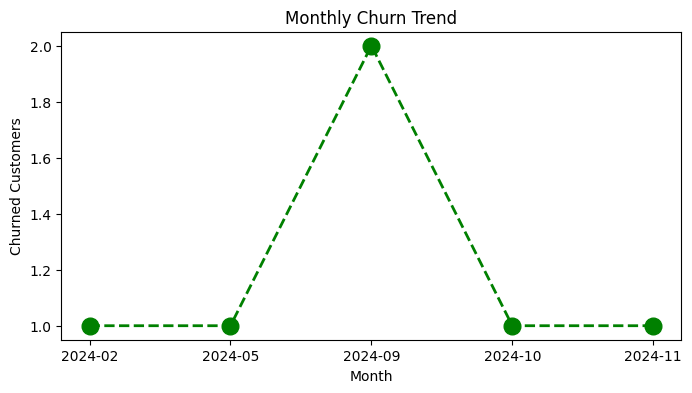

In [76]:
#1. Monthly Churn Trend (Time Series KPI)
df_visual["cancellation_month"]=df_visual["cancellation_date"].dt.to_period("M")

churn_trend=df_visual[df_visual["churn_flag"]==1].groupby("cancellation_month").size()

plt.figure(figsize=(8,4))
plt.style.use('seaborn-v0_8-colorblind')
plt.plot(churn_trend.index.astype(str),churn_trend.values,color="green",marker="o",linestyle="dashed",linewidth=2,markersize=12)
plt.title("Monthly Churn Trend")
plt.xlabel("Month")
plt.ylabel("Churned Customers")
plt.show()

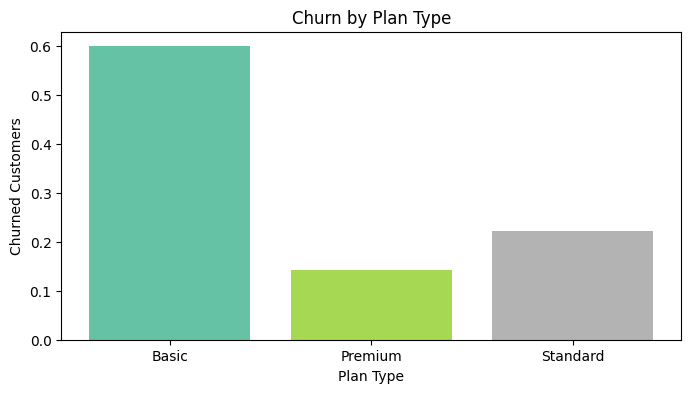

In [77]:
#2. Churn by Plan Type
churn_plan=df_visual.groupby("plan_type")["churn_flag"].mean().reset_index()

plt.figure(figsize=(8,4))
colors=plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.bar(churn_plan["plan_type"],churn_plan["churn_flag"],color=colors)
plt.title("Churn by Plan Type")
plt.xlabel("Plan Type")
plt.ylabel("Churned Customers")
plt.show()

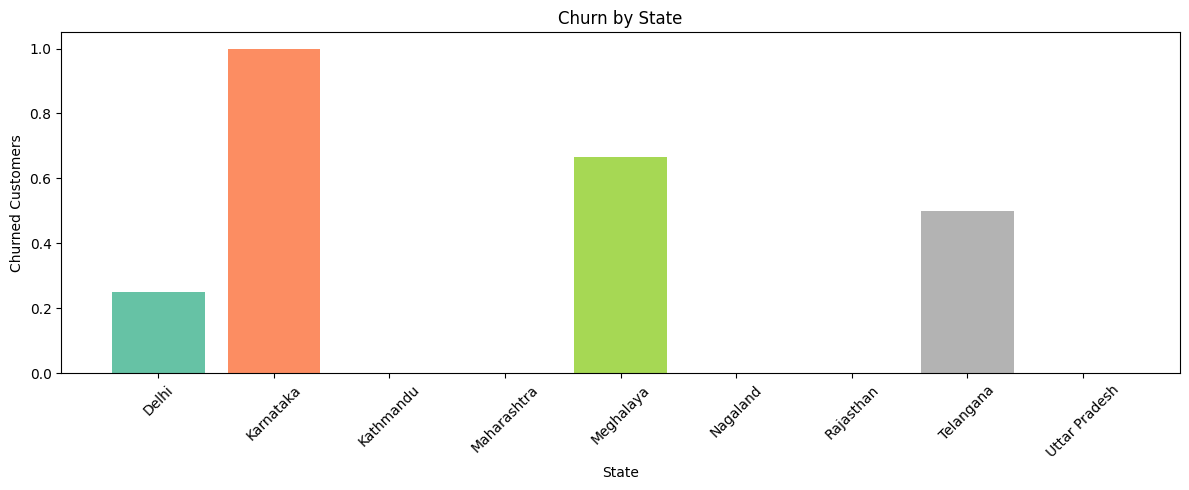

In [78]:
#3. Churn by States
churn_plan=df_visual.groupby("state")["churn_flag"].mean().reset_index()

plt.figure(figsize=(12,5))
colors=plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.bar(churn_plan["state"],churn_plan["churn_flag"],color=colors)
plt.title("Churn by State")
plt.xlabel("State")
plt.ylabel("Churned Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [79]:
#Encoding- Convert str to numeric so that we can find correlation between features

In [80]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [81]:
# Incorrect method of encoding - as numbers are not assigned based on priority
df_encoded=df_visual[[
         'plan_type', 'contract_type', 'churn_score','churn_flag', 'escalations',  'churn_risk'
]]

cat_cols=["plan_type","contract_type","churn_risk"]
for col in cat_cols:
    df_encoded[col]=df_encoded[col].astype("category").cat.codes

In [82]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,2,0,12,0,0,1
1,1,0,91,1,1,0
2,0,1,34,0,0,1
3,1,0,8,0,0,1
4,2,1,88,1,1,0


<Axes: >

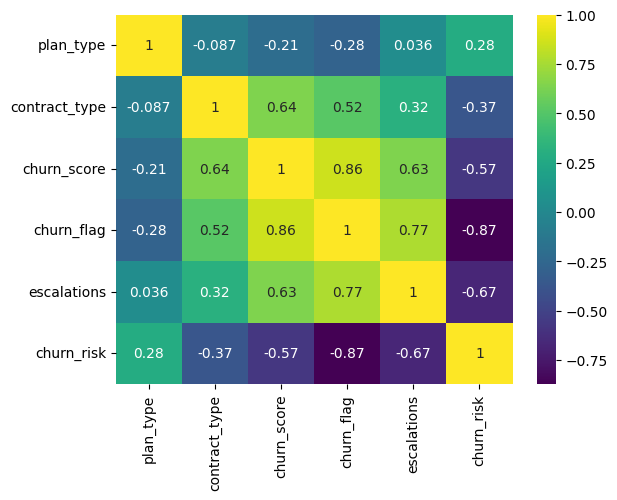

In [83]:
#Heatmap
sns.heatmap(df_encoded.corr(),annot=True,cmap="viridis")

In [84]:
# Correct method of encoding - based on priority
df_encoded=df_visual[[
         'plan_type', 'contract_type', 'churn_score','churn_flag', 'escalations',  'churn_risk'
]]
order_mappings={"plan_type":["Basic","Standard","Premium"],
                "contract_type":["Monthly","Annual"],
                "churn_risk":["Low","Mid","High"]}
for col,order in order_mappings.items():
    df_encoded[col]=pd.Categorical(df_encoded[col].astype("category"),categories=order,ordered=True).codes

In [85]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,escalations,churn_risk
0,1,1,12,0,0,0
1,2,1,91,1,1,2
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,1,2


<Axes: >

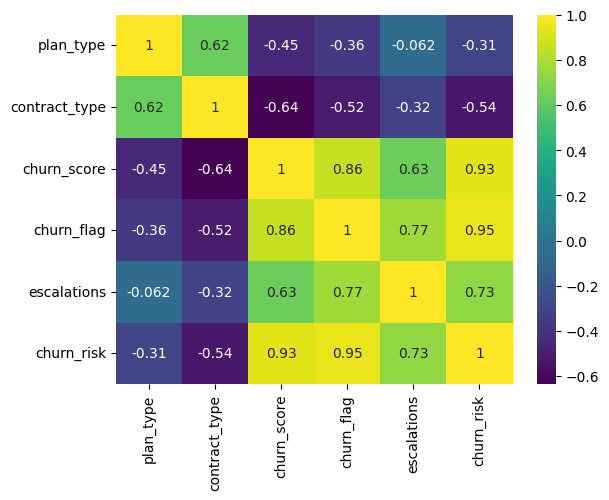

In [86]:
sns.heatmap(df_encoded.corr(),annot=True,cmap="viridis")

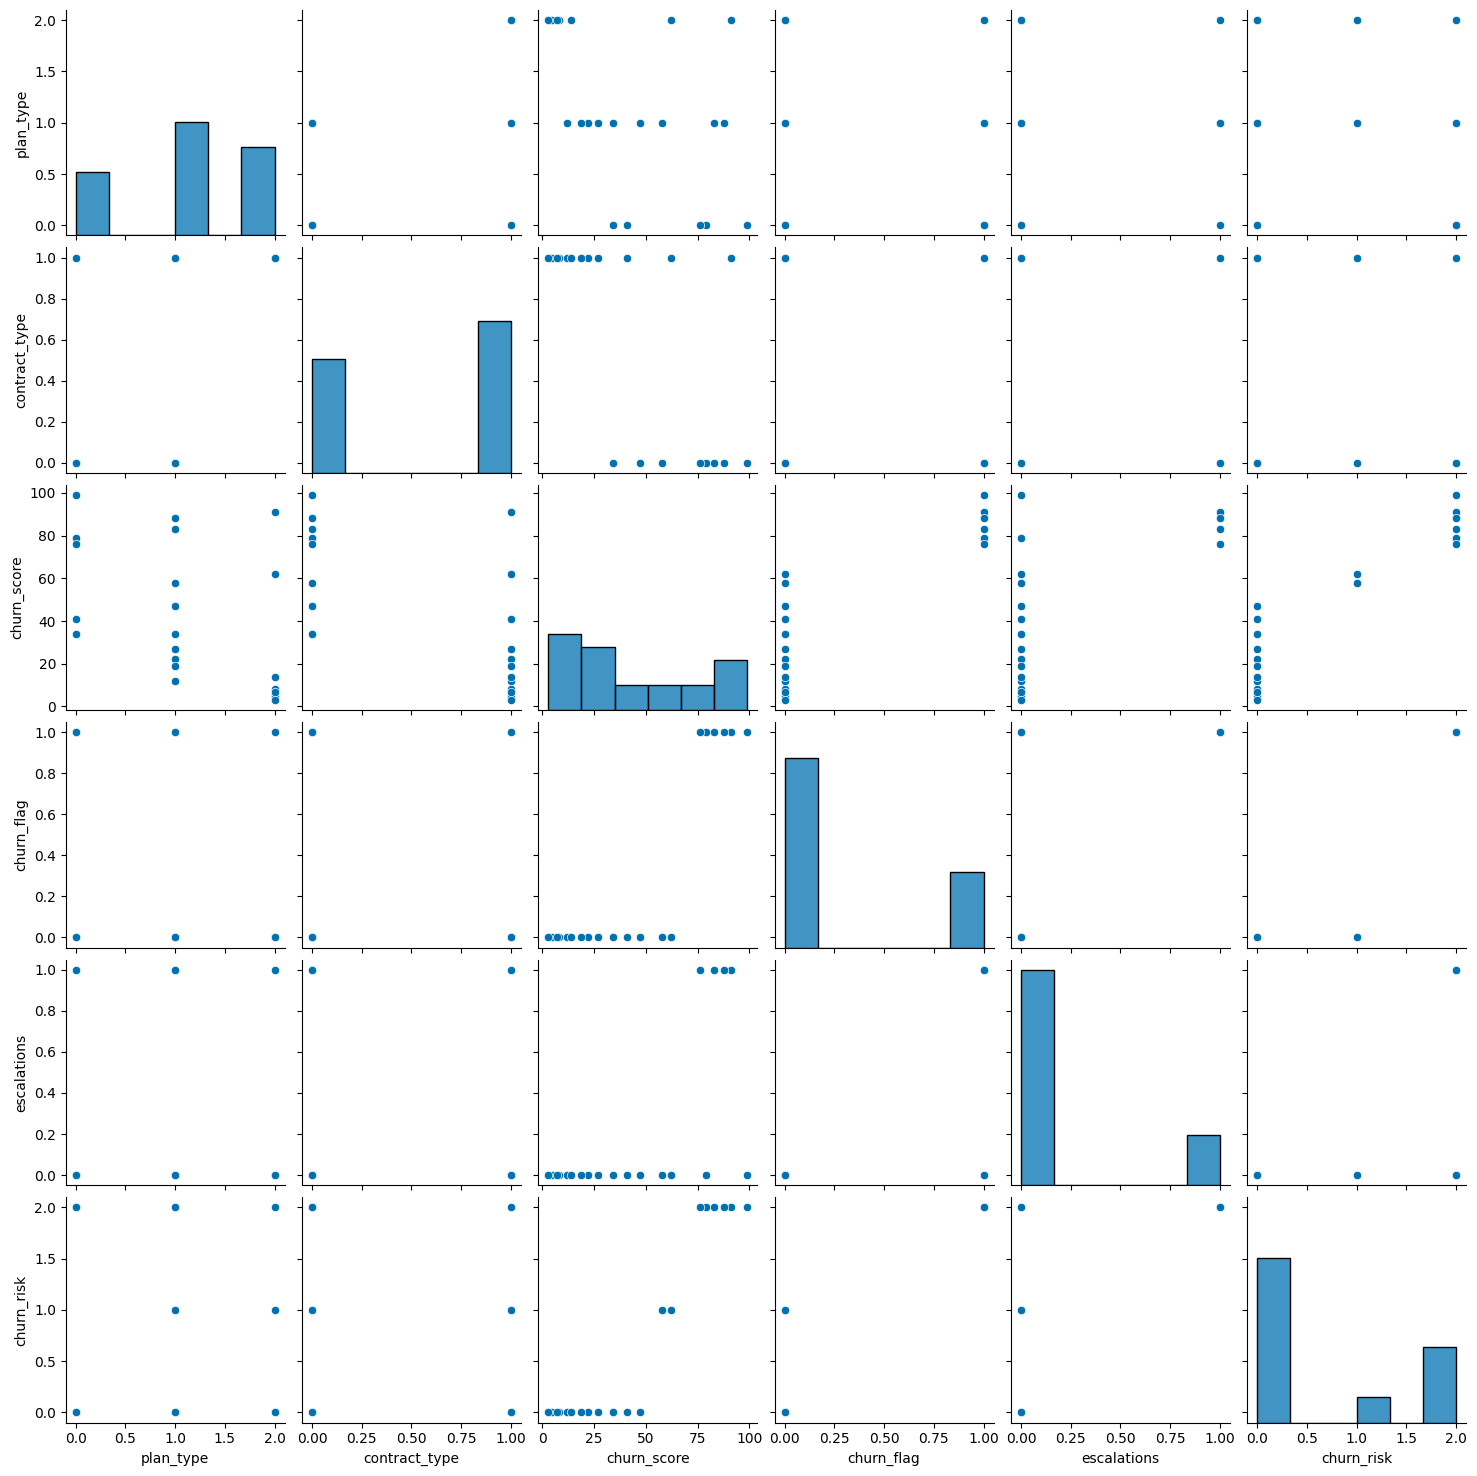

In [87]:
#Pairplot- Relationship in a dataset
sns.pairplot(df_encoded)

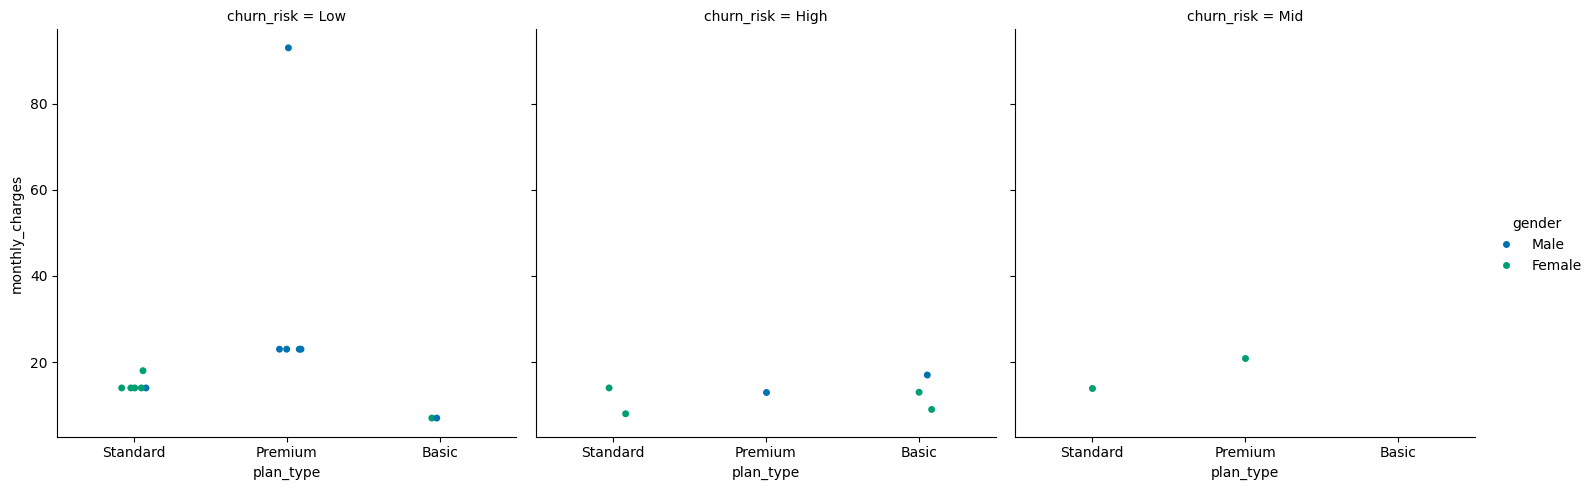

In [88]:
#Catplot/Facegrid Plot  -Multi-dim Comparision
sns.catplot(data=df_visual,x="plan_type",y="monthly_charges",hue="gender",col="churn_risk")

In [89]:
pd.pivot_table(
    data=df_visual,
    index="plan_type",
    values="churn_flag",
    aggfunc= 'mean',
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [90]:
pd.pivot_table(
    data=df_visual,
    index="plan_type",
    values=["monthly_charges","customerid","churn_flag"],
    aggfunc= {
    "monthly_charges":"sum",
    "customerid":"nunique",
    "churn_flag":"mean"
    }
).reset_index()

,plan_type,churn_flag,customerid,monthly_charges
0,Basic,0.600000,5,52.95
1,Premium,0.142857,7,218.93
2,Standard,0.222222,9,123.91


In [91]:
#Working with SQL in Python

In [93]:
#create db in sql
conn=sqlite3.connect("test_database.sqlite")
#table details
conn.execute("""create table if not exists users(first_name text,country text,budget integer)""")

#commit and save
conn.commit()

In [94]:
#insert data
cursor=conn.cursor()

#Write sql query to insert records in sql table
cursor.execute(
    """
    insert into users values('Madhav','India',5000),('Rishabh','Germany',2500),('Vidhika','India',3500)
    """
)
#Commit and save
conn.commit()

print("Data inserted successfully")

Data inserted successfully


In [95]:
#Check inserted data in table
conn=sqlite3.connect("test_database.sqlite")
df_results=pd.read_sql("""select *from users""",conn)
df_results

,first_name,country,budget
0,Madhav,India,5000
1,Rishabh,Germany,2500
2,Vidhika,India,3500
3,Madhav,India,5000
4,Rishabh,Germany,2500
5,Vidhika,India,3500


In [96]:
#Aggregation
query="""
select country,sum(budget) as total_budget from users group by country
"""

df_agg=pd.read_sql(query,conn)
df_agg

,country,total_budget
0,Germany,5000
1,India,17000


In [97]:
#Always close the connection with db once the task is over
conn.close()